[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhimingkuang/Harvard-AM-115/blob/main/12_earth_age/heat_equation_for_student.ipynb)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.sparse as sparse
import time
import IPython.display as IP

- x is the distance to the center of the Earth, in km.
- y is the temperature at that distance, in degrees Celsius.
- t is in time, in million years.

In [ ]:
radius_earth = 6371  # km
# Define grid spacing in km
dx = 10
# Define the number of grid points
m = radius_earth // dx
# Define the grid
x = np.linspace(dx, m * dx, num=m, endpoint=True)
# Integration time
# Let time be in units of million of years
time_e = 100
# Initial condition
# uniform at 2000 degrees Celsius
y0 = np.ones(m) * 2000
# thermal diffusivity of rocks is 1.2e-6 m^2/s
D = 1.2e-6 / 1e6  # convert to km^2/second
D = D * (60 * 60 * 24 * 365.25)  # convert to km^2/year
D = D * 1e6  # convert to km^2/million years
# Define the Laplacian operator
e1 = np.ones((1, m))  # build a vector of ones
diags = np.concatenate((e1, -2.0 * e1, e1))  # diagonal entries
offsets = np.array([-1, 0, 1])  # which diagonals

A = sparse.dia_matrix((diags, offsets), shape=(m, m))  # diagonal matrix
A = A.tolil()
# Enforce Dirichlet BCs:
A = sparse.dia_matrix((diags, offsets), (m, m)).tolil()
A[0, :] = 0
A[0, 0] = -1
A[-1, -1] = -1
A = A.todia()

# Source term
b = np.zeros(m)
b[0] = 0.0  # Surface


# Use ode solvers for this; method of lines
def F(t, y, D, A, b, dx):
    """RHS of the heat equation

    Args:
        t (float): 1-D independent variable (time)
        y (numpy.ndarray): N-D vector-valued function (state)
        D (float): diffusivity
        A (numpy.ndarray): Laplacian operator
        b (numpy.ndarray): source term
        dx (float): grid spacing

    Returns:
        numpy.ndarray: differential equation

    """
    return D * (sparse.csr_matrix.dot(A, y) + b) / (dx**2)


sol = solve_ivp(F, [0, time_e], y0, args=(D, A, b, dx), max_step=1.0, dense_output=True)
t = sol.t
y = sol.y

In [33]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

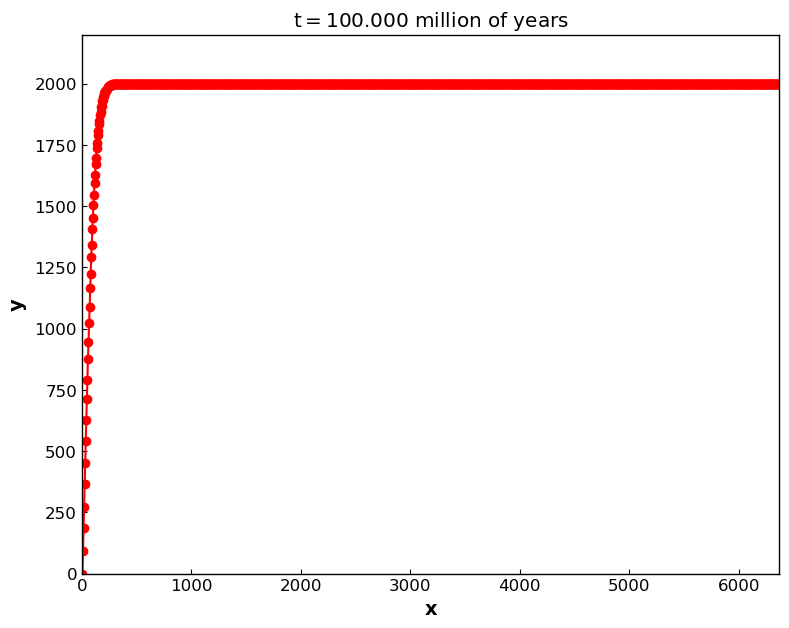

In [34]:
# Alternative way to animate the solution using FuncAnimation
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(1, 1, 1)

for i, time in enumerate(t):
    ax.cla()
    ax.plot(x, y[:, i], "r-o")
    ax.set_xlim(0, radius_earth)
    ax.set_ylim(0, 2200)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(r"$t = %.3f$ million of years" % time)

    IP.display(fig)
    IP.clear_output(wait=True)
    plt.pause(0.01)

In [35]:
# Find the time when the temperature gradient drops below 25°C per
# kilometer. That’s the age of Earth determined by Kelvin.

gradient = np.gradient(y, dx)
gradient_magnitude = np.abs(gradient)
threshold = 25  # °C/km
age_of_earth = t[np.where(gradient_magnitude < threshold)[1][0]]

In [36]:
# dimensions are
# distance to the center of the Earth in km, and time
y.shape

(1274, 184)

In [37]:
# steps are 10 km
# This is the change in temperature for a single time step
# Celsius per 10 km
threshold = 25

for t in range(y.shape[1]):

    # print(f"Time step {t}: Temperature change = {(y[:, t][1] - y[:, t][0]) / 10} °C/km")

    if t < 10:
        continue

    if (y[:, t][1] - y[:, t][0]) / dx < threshold:
        print(
            f"Time step {t}: Temperature change = {(y[:, t][1] - y[:, t][0]) / dx} °C/km"
        )
        print(f"Age of Earth determined by Kelvin: {t} million years")
        break

Time step 99: Temperature change = 24.95547829054538 °C/km
Age of Earth determined by Kelvin: 99 million years
